# Downstream clustering and trajectory inference for stGP Microglia

This notebook uses the saved stGP outputs for the mouse brain MERFISH microglia analysis. It focuses on one `mouse_id` at a time, clusters cells in the stGP spatial embedding with a symmetric KNN graph and spectral clustering, then runs Slingshot trajectory inference with the conda environment including `pyslingshot`.

## 1. Setup and load stGP outputs

In [1]:
%matplotlib inline
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import plots as mouse_plots
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import SpectralClustering
from pyslingshot import Slingshot

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams['figure.dpi'] = 120

ROOT = Path.cwd()
CELLTYPE = 'Microglia'
STGP_DIR = ROOT / 'Results' / 'stgp' / CELLTYPE
ADATA_PATH = STGP_DIR / 'adata_with_scores.h5ad'
OUT_DIR = STGP_DIR / 'downstream_cluster'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ROOT / 'Figures' / CELLTYPE
FIG_DIR.mkdir(parents=True, exist_ok=True)

MOUSE_ID = '97'
RANDOM_STATE = 1234
adata_full = mouse_plots.read_h5ad_compat(ADATA_PATH, cache_dir=OUT_DIR)
mask = adata_full.obs['mouse_id'].astype(str).to_numpy() == str(MOUSE_ID)
adata = adata_full[mask].copy()
label_suffix = f'mouse_{MOUSE_ID}'

/home/byual/anaconda3/envs/NicheScope/lib/python3.9/site-packages/pyslingshot/slingshot.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## 2. KNN spectral clustering in the stGP spatial embedding

In [2]:
b = np.asarray(adata.obsm['X_stgp_spatial'])
truth = adata.obs['subregion'].astype('category').cat.remove_unused_categories()
n_clusters = 4
k_nn = min(max(2, int(np.round(np.sqrt(b.shape[0])))), b.shape[0] - 1)

nn = NearestNeighbors(n_neighbors=k_nn + 1, metric='euclidean').fit(b).kneighbors(return_distance=False)[:, 1:]
rows = np.repeat(np.arange(nn.shape[0]), k_nn)
cols = nn.ravel()
knn_graph = sp.csr_matrix((np.ones(rows.size), (rows, cols)), shape=(b.shape[0], b.shape[0]))
knn_graph = knn_graph.maximum(knn_graph.T)

clusterlabel = SpectralClustering(
    n_clusters=n_clusters,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=RANDOM_STATE,
).fit_predict(knn_graph) + 1

adata.obs['stGP_domain'] = pd.Categorical(clusterlabel.astype(str))
ctab = pd.crosstab(adata.obs['stGP_domain'], truth, rownames=['stGP'], colnames=['subregion'])
display(ctab)
ctab.to_csv(OUT_DIR / f'{label_suffix}_stgp_domain_subregion_crosstab.csv')

subregion,CC/ACO,CTX_L1/MEN,CTX_L2/3,CTX_L4/5/6,STR_CP/ACB,STR_LS/NDB,VEN
stGP,,,,,,,
1,192,95,147,193,519,331,1
2,5,133,657,184,242,79,0
3,319,5,6,7,196,10,2
4,280,2,0,1,19,1,0


## 3. Slingshot trajectory inference

In [3]:
DRM = np.asarray(adata.obsm['X_stgp_spatial'])
if DRM.shape[0] != adata.n_obs:
    DRM = DRM.T
adata.obsm['X_DRM'] = np.asarray(DRM)
adata.obs['clusterlabel'] = pd.Categorical(adata.obs['stGP_domain'].astype(str))

cats = adata.obs['clusterlabel'].cat.categories.astype(str)
print('Cluster categories:', list(cats))

start_cluster = '4'
start_node = int(np.where(cats == start_cluster)[0][0])
print(f'Start cluster: {start_cluster} (start_node={start_node})')

sl = Slingshot(adata, celltype_key='clusterlabel', obsm_key='X_DRM', start_node=start_node)
sl.fit(num_epochs=10)

Cluster categories: ['1', '2', '3', '4']
Start cluster: 4 (start_node=3)


  0%|          | 0/10 [00:00<?, ?it/s]/home/byual/anaconda3/envs/NicheScope/lib/python3.9/site-packages/pyslingshot/slingshot.py:333: RuntimeWarning: invalid value encountered in divide
  cell_weights = z_prime / np.nanmax(z_prime, axis=1, keepdims=True) #rowMins(D) / D
 10%|█         | 1/10 [00:02<00:21,  2.41s/it]

/home/byual/anaconda3/envs/NicheScope/lib/python3.9/site-packages/pyslingshot/slingshot.py:333: RuntimeWarning: invalid value encountered in divide
  cell_weights = z_prime / np.nanmax(z_prime, axis=1, keepdims=True) #rowMins(D) / D
100%|██████████| 10/10 [00:23<00:00,  2.37s/it]


In [4]:
adata.obs['slingPseudotime_1'] = sl.unified_pseudotime

if sl.curves is not None and sl.cell_weights is not None:
    for l_idx, curve in enumerate(sl.curves):
        pt = curve.pseudotimes_interp.copy()
        weight = sl.cell_weights[:, l_idx].copy()
        pt[weight <= 0] = np.nan
        adata.obs[f'slingPseudotime_{l_idx + 1}'] = pt
        adata.obs[f'slingCurveWeight_{l_idx + 1}'] = weight

adata.obs[['clusterlabel', 'subregion', 'slingPseudotime_1']].head()

,clusterlabel,subregion,slingPseudotime_1
3615378900220100285-97,2,CTX_L2/3,18.653134
3615378900220100290-97,2,CTX_L2/3,20.614100
3615378900220200026-97,2,CTX_L2/3,20.533276
3615378900230100262-97,2,CTX_L1/MEN,20.764129
3615378900230100309-97,2,CTX_L2/3,20.805265


## 4. Visualise and save outputs

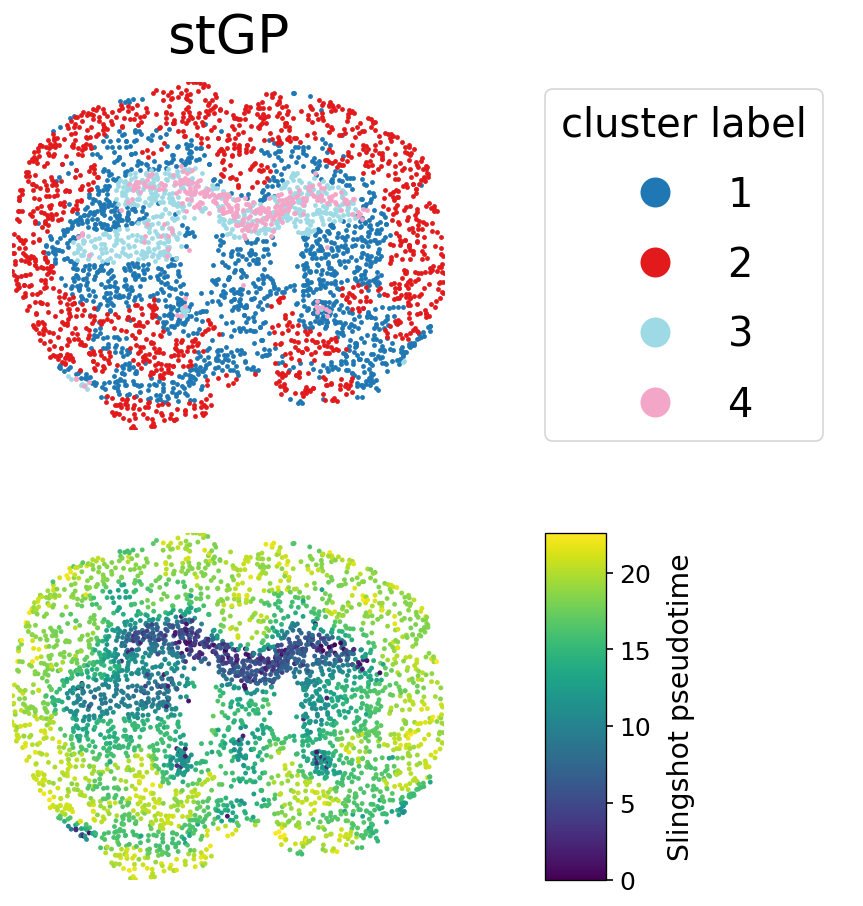

In [5]:
from matplotlib.lines import Line2D

cluster_palette = {
    1: "#1f78b4",
    2: "#e31a1c",
    3: "#9edae5",
    4: "#f4a6c8",
    5: "#33a02c",
    6: "#ff7f00",
    7: "#6a3d9a",
    8: "#b15928",
}

def cluster_color(label, default="#7f7f7f"):
    try:
        key = int(label)
    except (TypeError, ValueError):
        key = str(label)
    return cluster_palette.get(key, default)

xy = np.asarray(adata.obsm["spatial"], dtype=float)
pt = pd.to_numeric(adata.obs["slingPseudotime_1"], errors="coerce").to_numpy(float)
labels = pd.Categorical(adata.obs["clusterlabel"].astype(str))
cats = labels.categories.astype(str).tolist()

x = xy[:, 0]
y = -xy[:, 1]
label_arr = labels.astype(str)

fig = plt.figure(figsize=(7.9, 7.55), constrained_layout=False)
gs = fig.add_gridspec(
    2,
    2,
    left=0.01,
    right=0.99,
    top=0.90,
    bottom=0.02,
    width_ratios=[1.00, 0.50],
    height_ratios=[1, 1],
    wspace=0.025,
    hspace=0.30,
)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0, sharey=ax0)
leg_ax = fig.add_subplot(gs[0, 1])
cbar_gs = gs[1, 1].subgridspec(1, 3, width_ratios=[0.20, 0.07, 0.73], wspace=0.0)
cax = fig.add_subplot(cbar_gs[0, 0])

for label in cats:
    mask = label_arr == str(label)
    ax0.scatter(x[mask], y[mask], s=8.5, linewidths=0, rasterized=True, color=cluster_color(label), label=str(label))

scat = ax1.scatter(x, y, c=pt, s=8.5, cmap="viridis", linewidths=0, rasterized=True)

for ax in [ax0, ax1]:
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.max(), y.min())
ax0.set_title("stGP", fontsize=32, fontweight="normal", pad=18)

leg_ax.axis("off")
legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=cluster_color(label), markeredgecolor="none", markersize=18, label=str(label))
    for label in cats
]
leg_ax.legend(
    handles=legend_handles,
    title="cluster label",
    fontsize=24,
    title_fontsize=24,
    loc="upper left",
    bbox_to_anchor=(0.0, 0.98),
    borderaxespad=0,
    handletextpad=0.8,
    labelspacing=0.75,
)

cbar = plt.colorbar(scat, cax=cax)
cbar.set_label("Slingshot pseudotime", fontsize=17, labelpad=10)
cbar.ax.tick_params(labelsize=15, length=4, width=1.0)
slingshot_stem = f"{label_suffix}_slingshot_spatial" if label_suffix != "mouse_97" else "mouse_97_slingshot_spatial"
fig.savefig(FIG_DIR / f"{slingshot_stem}.png", dpi=400, bbox_inches=None, pad_inches=0)
fig.savefig(FIG_DIR / f"{slingshot_stem}.pdf", bbox_inches=None, pad_inches=0)
plt.show()

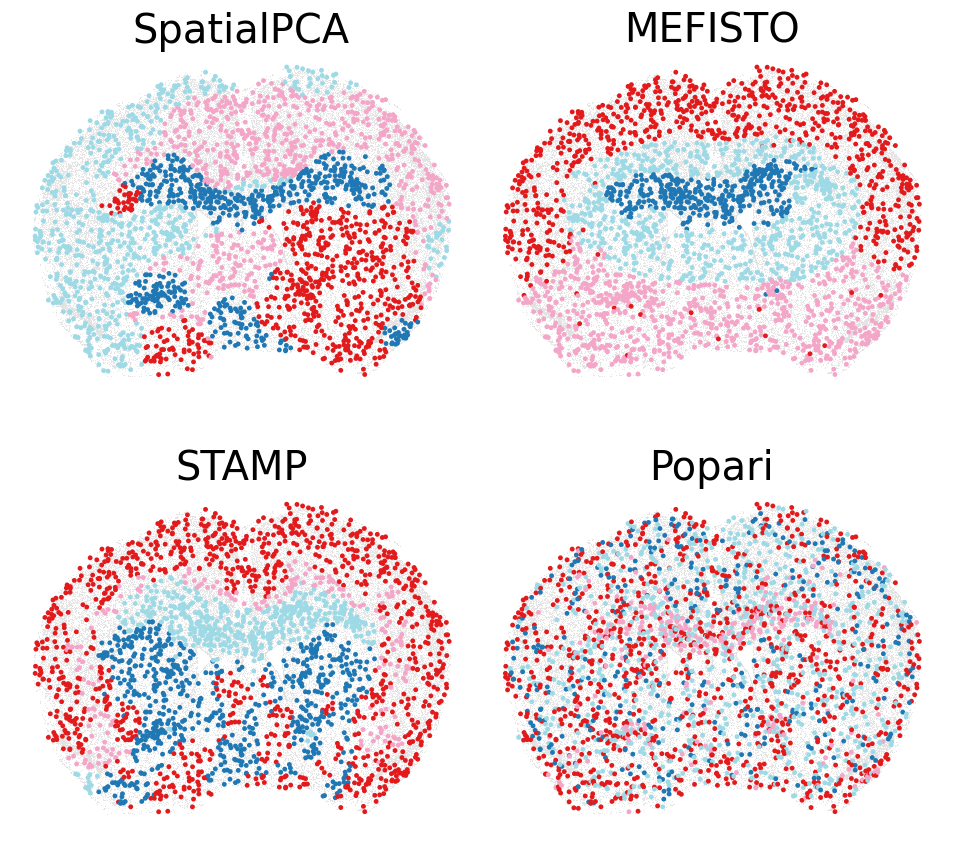

In [6]:
# Fig5 benchmark clustering panel for mouse 101 across baseline methods.
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import plots as mouse_plots
from plots import _bg_per_mouse
from sklearn.preprocessing import StandardScaler

load_method = mouse_plots.load_method

BASELINE_DIRS = {
    'SpatialPCA': ROOT / 'Results' / 'baselines' / 'spatialpca' / CELLTYPE,
    'MEFISTO': ROOT / 'Results' / 'baselines' / 'mefisto' / CELLTYPE,
    'STAMP': ROOT / 'Results' / 'baselines' / 'stamp' / CELLTYPE,
    'Popari': ROOT / 'Results' / 'baselines' / 'popari' / CELLTYPE,
}
benchmark_results = {
    method: load_method(method, result_dir, celltype=CELLTYPE)
    for method, result_dir in BASELINE_DIRS.items()
}
adata_all_qc = mouse_plots.read_h5ad_compat(ROOT / 'data' / 'qc' / 'aging_coronal_qc.h5ad')

if 'cluster_color' not in globals():
    cluster_palette = {
        1: '#1f78b4',
        2: '#e31a1c',
        3: '#9edae5',
        4: '#f4a6c8',
        5: '#33a02c',
        6: '#ff7f00',
        7: '#6a3d9a',
        8: '#b15928',
    }

    def cluster_color(label, default='#7f7f7f'):
        try:
            key = int(label)
        except (TypeError, ValueError):
            key = str(label)
        return cluster_palette.get(key, default)


def _xy_from_adata(adata_obj):
    xy = adata_obj.obsm['spatial'] if 'spatial' in adata_obj.obsm else adata_obj.obs[['center_x', 'center_y']]
    return np.asarray(xy, dtype=float)


def _embedding_for_method(method_result):
    if method_result.method == 'SpatialPCA' and 'X_spatialpca' in method_result.adata.obsm:
        emb = np.asarray(method_result.adata.obsm['X_spatialpca'], dtype=float)
    else:
        emb = method_result.scores.to_numpy(dtype=float)
    return np.nan_to_num(emb, nan=0.0, posinf=0.0, neginf=0.0)


def _spectral_knn_labels(X, n_clusters, *, random_state=42):
    X = np.asarray(X, dtype=float)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    n = X.shape[0]
    if n <= n_clusters:
        return np.arange(n, dtype=int) % max(n_clusters, 1)
    Xs = StandardScaler().fit_transform(X)
    k_nn = min(max(2, int(np.round(np.sqrt(n)))), n - 1)
    nn = NearestNeighbors(n_neighbors=k_nn + 1, metric='euclidean').fit(Xs).kneighbors(return_distance=False)[:, 1:]
    rows = np.repeat(np.arange(nn.shape[0]), k_nn)
    cols = nn.ravel()
    graph = sp.csr_matrix((np.ones(rows.size), (rows, cols)), shape=(n, n))
    graph = graph.maximum(graph.T)
    return SpectralClustering(n_clusters=n_clusters, affinity='precomputed', assign_labels='kmeans', random_state=random_state).fit_predict(graph)


def _cluster_labels_for_mouse(method_result, mouse_id):
    emb = _embedding_for_method(method_result)
    mouse_ids = method_result.adata.obs['mouse_id'].astype(str).to_numpy()
    mask = mouse_ids == str(mouse_id)
    if method_result.method == 'STAMP':
        labels = np.argmax(emb, axis=1).astype(int) + 1
        return labels[mask]
    region_labels = method_result.adata.obs['region'].astype(str).to_numpy() if 'region' in method_result.adata.obs.columns else None
    n_clusters = max(2, len(np.unique(region_labels)) if region_labels is not None else 6)
    n_eff = min(max(2, n_clusters), max(1, int(mask.sum()) - 1))
    return _spectral_knn_labels(emb[mask], n_eff, random_state=42) + 1

mouse_id = '101'
age_label = 34.5
method_order = ['SpatialPCA', 'MEFISTO', 'STAMP', 'Popari']
fig, axes = plt.subplots(2, 2, figsize=(3.95 * 2, 3.78 * 2), constrained_layout=False, squeeze=False)
fig.subplots_adjust(left=0.01, right=0.99, top=0.94, bottom=0.02, wspace=0.025, hspace=0.10)
for ax, method in zip(axes.ravel(), method_order):
    method_result = benchmark_results[method]
    labels = _cluster_labels_for_mouse(method_result, mouse_id)
    obs = method_result.adata.obs
    xy = _xy_from_adata(method_result.adata)
    mouse_ids = obs['mouse_id'].astype(str).to_numpy()
    mask = mouse_ids == mouse_id
    bg_by_mouse = _bg_per_mouse(adata_all_qc, mouse_ids)
    if mouse_id in bg_by_mouse:
        bg = bg_by_mouse[mouse_id]
        ax.scatter(bg[:, 0], bg[:, 1], c='#E0E0E0', s=0.36, linewidths=0, rasterized=True, zorder=1)
    ax.scatter(xy[mask, 0], xy[mask, 1], c=[cluster_color(lbl) for lbl in labels], s=8.5, linewidths=0, rasterized=True, zorder=2)
    ax.set_aspect('equal')
    ax.set_title(method, fontsize=24, fontweight='normal', pad=4)
    ax.axis('off')
fig.savefig(FIG_DIR / f'Microglia_benchmark_clustering_mouse_{mouse_id}_age_{age_label:.1f}mo.png', dpi=400, bbox_inches=None, pad_inches=0)
fig.savefig(FIG_DIR / f'Microglia_benchmark_clustering_mouse_{mouse_id}_age_{age_label:.1f}mo.pdf', bbox_inches=None, pad_inches=0)
plt.show()

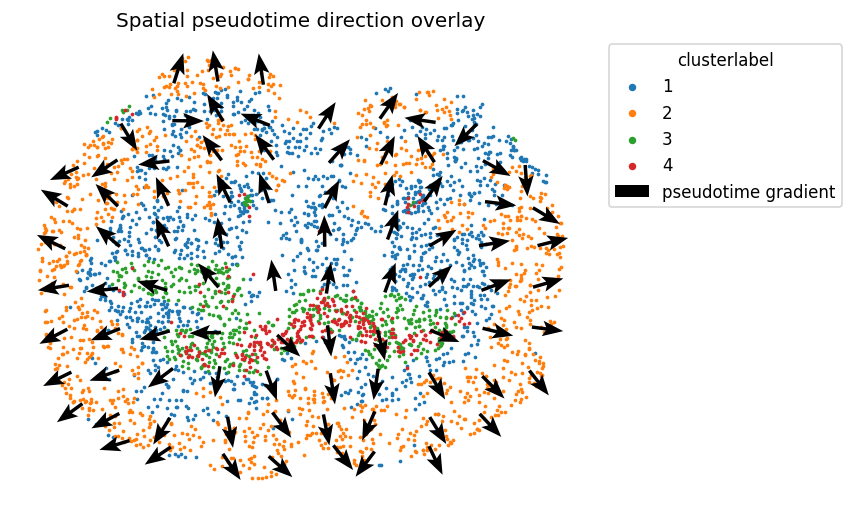

In [7]:
# Arrow overlay: local spatial pseudotime gradient, from lower to higher pseudotime.
GRIDNUM = 10
MIN_CELLS_PER_GRID = 10
ARROW_LENGTH_FRAC = 0.75

xy = np.asarray(adata.obsm['spatial'])
pt = adata.obs['slingPseudotime_1'].to_numpy(dtype=float)
valid = np.isfinite(pt) & np.all(np.isfinite(xy), axis=1)
xy_valid = xy[valid]
pt_valid = pt[valid]

x_edges = np.linspace(xy_valid[:, 0].min(), xy_valid[:, 0].max(), GRIDNUM + 1)
y_edges = np.linspace(xy_valid[:, 1].min(), xy_valid[:, 1].max(), GRIDNUM + 1)
x_bin = np.digitize(xy_valid[:, 0], x_edges[1:-1])
y_bin = np.digitize(xy_valid[:, 1], y_edges[1:-1])

mean_pt = np.full((GRIDNUM, GRIDNUM), np.nan)
mean_xy = np.full((GRIDNUM, GRIDNUM, 2), np.nan)
for i in range(GRIDNUM):
    for j in range(GRIDNUM):
        m = (x_bin == i) & (y_bin == j)
        if int(m.sum()) >= MIN_CELLS_PER_GRID:
            mean_pt[i, j] = float(np.nanmean(pt_valid[m]))
            mean_xy[i, j] = np.nanmean(xy_valid[m], axis=0)

mean_pt_pad = np.pad(mean_pt, 1, constant_values=np.nan)
mean_xy_pad = np.pad(mean_xy, ((1, 1), (1, 1), (0, 0)), constant_values=np.nan)

arrow_start, arrow_vec = [], []
for i in range(GRIDNUM):
    for j in range(GRIDNUM):
        if not np.isfinite(mean_pt[i, j]):
            continue
        grad = np.zeros(2, dtype=float)
        center = mean_xy[i, j]
        i_pad, j_pad = i + 1, j + 1
        for di in (-1, 0, 1):
            for dj in (-1, 0, 1):
                if di == 0 and dj == 0:
                    continue
                ni, nj = i_pad + di, j_pad + dj
                if not np.isfinite(mean_pt_pad[ni, nj]):
                    continue
                direction = mean_xy_pad[ni, nj] - center
                dist = np.linalg.norm(direction)
                if dist > 0:
                    grad += (mean_pt_pad[ni, nj] - mean_pt[i, j]) * direction / dist
        norm = np.linalg.norm(grad)
        if norm > 0:
            arrow_start.append(center)
            arrow_vec.append(grad / norm)

arrow_start = np.asarray(arrow_start)
arrow_vec = np.asarray(arrow_vec)
cell_size = min(np.diff(x_edges).mean(), np.diff(y_edges).mean())
arrow_vec = arrow_vec * cell_size * ARROW_LENGTH_FRAC

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
for label in adata.obs['clusterlabel'].cat.categories:
    mask = adata.obs['clusterlabel'].astype(str).to_numpy() == str(label)
    ax.scatter(xy[mask, 0], xy[mask, 1], s=5, linewidths=0, rasterized=True, label=str(label))
if len(arrow_start) > 0:
    ax.quiver(arrow_start[:, 0], arrow_start[:, 1], arrow_vec[:, 0], arrow_vec[:, 1], angles='xy', scale_units='xy', scale=1, color='black', width=0.006, headwidth=4.5, headlength=6.0, headaxislength=5.0, label='pseudotime gradient')
ax.set_aspect('equal')
ax.invert_yaxis()
ax.axis('off')
ax.set_title('Spatial pseudotime direction overlay')
ax.legend(title='clusterlabel', markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.savefig(OUT_DIR / f'{label_suffix}_slingshot_arrow_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
OUT_H5AD = OUT_DIR / f'{label_suffix}_stgp_cluster_slingshot.h5ad'
OUT_OBS = OUT_DIR / f'{label_suffix}_stgp_cluster_slingshot_obs.csv'

adata.write_h5ad(OUT_H5AD, compression='gzip')
adata.obs.to_csv(OUT_OBS)

print(f'Saved trajectory AnnData: {OUT_H5AD.resolve()}')
print(f'Saved trajectory obs: {OUT_OBS.resolve()}')

Saved trajectory AnnData: /import/home4/byual/stGP-0707/RealData_MouseBrainMERFISH/Results/stgp/Microglia/downstream_cluster/mouse_97_stgp_cluster_slingshot.h5ad
Saved trajectory obs: /import/home4/byual/stGP-0707/RealData_MouseBrainMERFISH/Results/stgp/Microglia/downstream_cluster/mouse_97_stgp_cluster_slingshot_obs.csv
